In [3]:
import os

print(os.listdir('/content'))

['.config', 'sample_data']


In [4]:
from zipfile import ZipFile

zip_path = "/content/drive/MyDrive/cisproj/archive (1).zip"

extract_path = "/content/AHCD"

with ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [5]:
import os

for root, dirs, files in os.walk("/content/AHCD"):
    print(root)

/content/AHCD
/content/AHCD/train images 13440x32x32
/content/AHCD/train images 13440x32x32/train
/content/AHCD/Train Images 13440x32x32
/content/AHCD/Train Images 13440x32x32/train
/content/AHCD/Test Images 3360x32x32
/content/AHCD/Test Images 3360x32x32/test
/content/AHCD/test images 3360x32x32
/content/AHCD/test images 3360x32x32/test
/content/AHCD/arabic handwritten characters dataset csv
/content/AHCD/Arabic Handwritten Characters Dataset CSV


In [6]:
# Load Dataset

import os
import cv2
import numpy as np
import pandas as pd

IMG_SIZE = 32

train_folder = "/content/AHCD/Train Images 13440x32x32/train"
test_folder = "/content/AHCD/Test Images 3360x32x32/test"

csv_folder = "/content/AHCD/Arabic Handwritten Characters Dataset CSV"

print("Training Images:", len(os.listdir(train_folder)))
print("Testing Images:", len(os.listdir(test_folder)))

print("\nCSV Files:")

for file in os.listdir(csv_folder):
    print(file)

Training Images: 13440
Testing Images: 3360

CSV Files:
csvTrainLabel 13440x1.csv
csvTestImages 3360x1024.csv
csvTestLabel 3360x1.csv
csvTrainImages 13440x1024.csv


In [7]:
# Load Images Using Filename Labels

import os
import cv2
import numpy as np

X_train = []
y_train = []

print("Loading Training Images...")

train_images = os.listdir(train_folder)

for img_name in train_images:

    img_path = os.path.join(train_folder, img_name)

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    img = img.astype("float32") / 255.0

    X_train.append(img.flatten())

    # Extract label from filename
    label = int(img_name.split("_")[-1].replace(".png",""))

    y_train.append(label-1)      # convert 1-28 to 0-27

print("Training Loaded!")

X_test = []
y_test = []

print("Loading Testing Images...")

test_images = os.listdir(test_folder)

for img_name in test_images:

    img_path = os.path.join(test_folder, img_name)

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    img = img.astype("float32") / 255.0

    X_test.append(img.flatten())

    label = int(img_name.split("_")[-1].replace(".png",""))

    y_test.append(label-1)

print("Testing Loaded!")

X_train=np.array(X_train)
X_test=np.array(X_test)

y_train=np.array(y_train)
y_test=np.array(y_test)

print("Done!")

Loading Training Images...
Training Loaded!
Loading Testing Images...
Testing Loaded!
Done!


In [8]:
print(y_train[:20])

[13  7  4 15  6  9  2 14  7 13 12 10 13 26 15 10  7 22 23  1]


In [9]:
# Check Dataset Information


print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

print("\nNumber of Classes :", len(np.unique(y_train)))

print("\nFirst 10 Labels:")
print(y_train[:10])

Training Shape : (13440, 1024)
Testing Shape : (3360, 1024)

Number of Classes : 28

First 10 Labels:
[13  7  4 15  6  9  2 14  7 13]


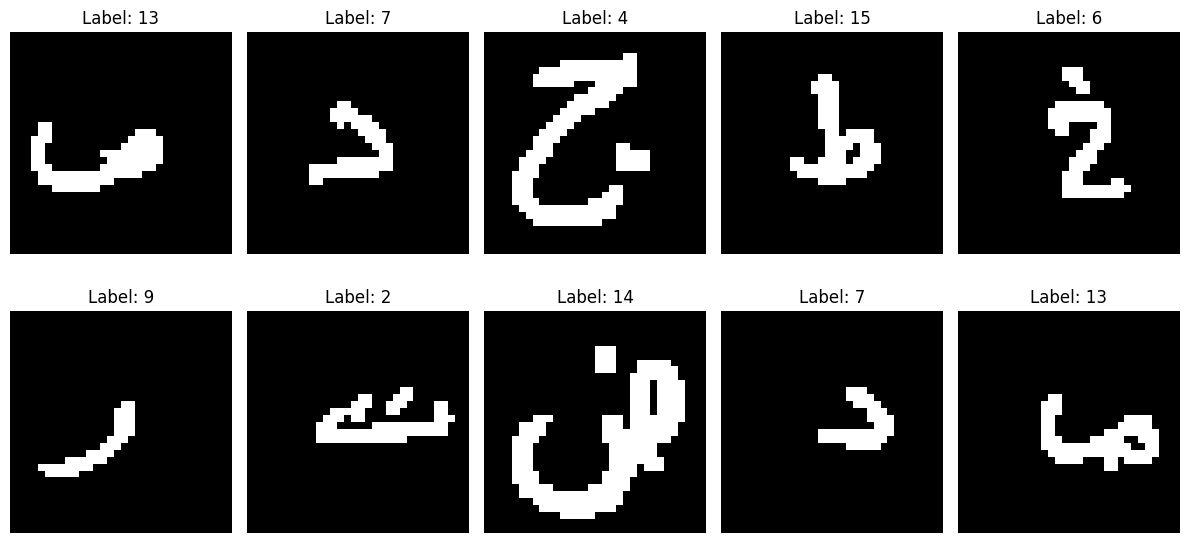

In [10]:
# Display Sample Images


import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i].reshape(32,32), cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

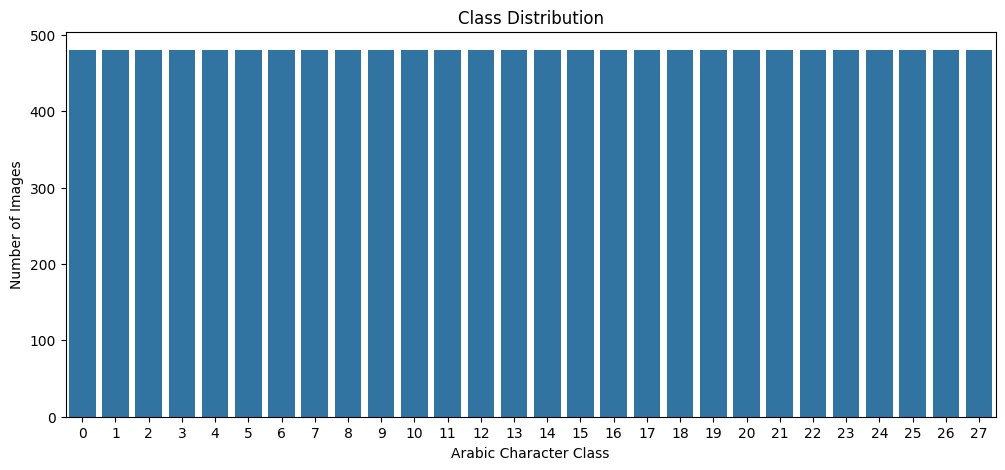

In [11]:
# Class Distribution


import seaborn as sns

plt.figure(figsize=(12,5))

sns.countplot(x=y_train)

plt.title("Class Distribution")
plt.xlabel("Arabic Character Class")
plt.ylabel("Number of Images")

plt.show()

In [12]:
# Build MLP Model


from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(512, 256),
    activation='relu',
    solver='adam',
    max_iter=50,
    random_state=42,
    verbose=True
)

print("MLP Model Created Successfully!")

MLP Model Created Successfully!


In [13]:
# Train the Model

print("Training Started...\n")

mlp.fit(X_train, y_train)

print("\nTraining Completed!")

Training Started...

Iteration 1, loss = 2.26497260
Iteration 2, loss = 1.30918654
Iteration 3, loss = 0.89236191
Iteration 4, loss = 0.63584079
Iteration 5, loss = 0.47222231
Iteration 6, loss = 0.36604938
Iteration 7, loss = 0.28229836
Iteration 8, loss = 0.21965404
Iteration 9, loss = 0.16047913
Iteration 10, loss = 0.12480609
Iteration 11, loss = 0.09817579
Iteration 12, loss = 0.07154390
Iteration 13, loss = 0.05749194
Iteration 14, loss = 0.04514049
Iteration 15, loss = 0.03353485
Iteration 16, loss = 0.02643267
Iteration 17, loss = 0.02117632
Iteration 18, loss = 0.01733594
Iteration 19, loss = 0.01438127
Iteration 20, loss = 0.01214985
Iteration 21, loss = 0.01058163
Iteration 22, loss = 0.00913432
Iteration 23, loss = 0.00831419
Iteration 24, loss = 0.00726105
Iteration 25, loss = 0.00647684
Iteration 26, loss = 0.00582629
Iteration 27, loss = 0.00535604
Iteration 28, loss = 0.00490175
Iteration 29, loss = 0.00453514
Iteration 30, loss = 0.00431573
Iteration 31, loss = 0.00389

/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


In [14]:
# Predict Test Images


y_pred = mlp.predict(X_test)

print("Prediction Completed!")

Prediction Completed!


In [15]:
# Accuracy


from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.8017857142857143


In [16]:
# Precision, Recall and F1 Score


from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Precision :", precision)
print("Recall    :", recall)
print("F1 Score  :", f1)

Precision : 0.8029901114434965
Recall    : 0.8017857142857143
F1 Score  : 0.8015664029199815


In [17]:
# Classification Report


from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.98      0.96       120
           1       0.90      0.93      0.91       120
           2       0.70      0.74      0.72       120
           3       0.78      0.76      0.77       120
           4       0.76      0.79      0.78       120
           5       0.74      0.79      0.77       120
           6       0.77      0.69      0.73       120
           7       0.80      0.82      0.81       120
           8       0.79      0.78      0.79       120
           9       0.76      0.86      0.81       120
          10       0.83      0.75      0.79       120
          11       0.85      0.79      0.82       120
          12       0.80      0.82      0.81       120
          13       0.72      0.82      0.77       120
          14       0.80      0.76      0.78       120
          15       0.77      0.82      0.80       120
          16       0.75      0.72      0.74       120
          17       0.70    

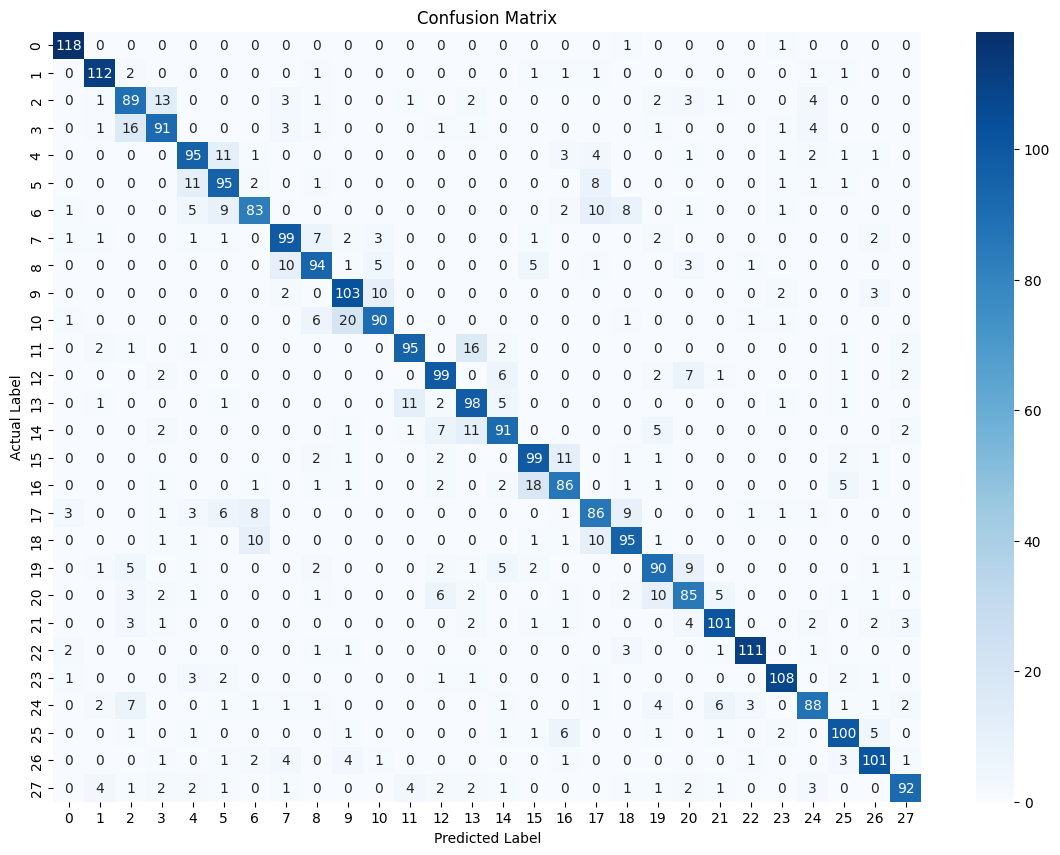

In [18]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(14,10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

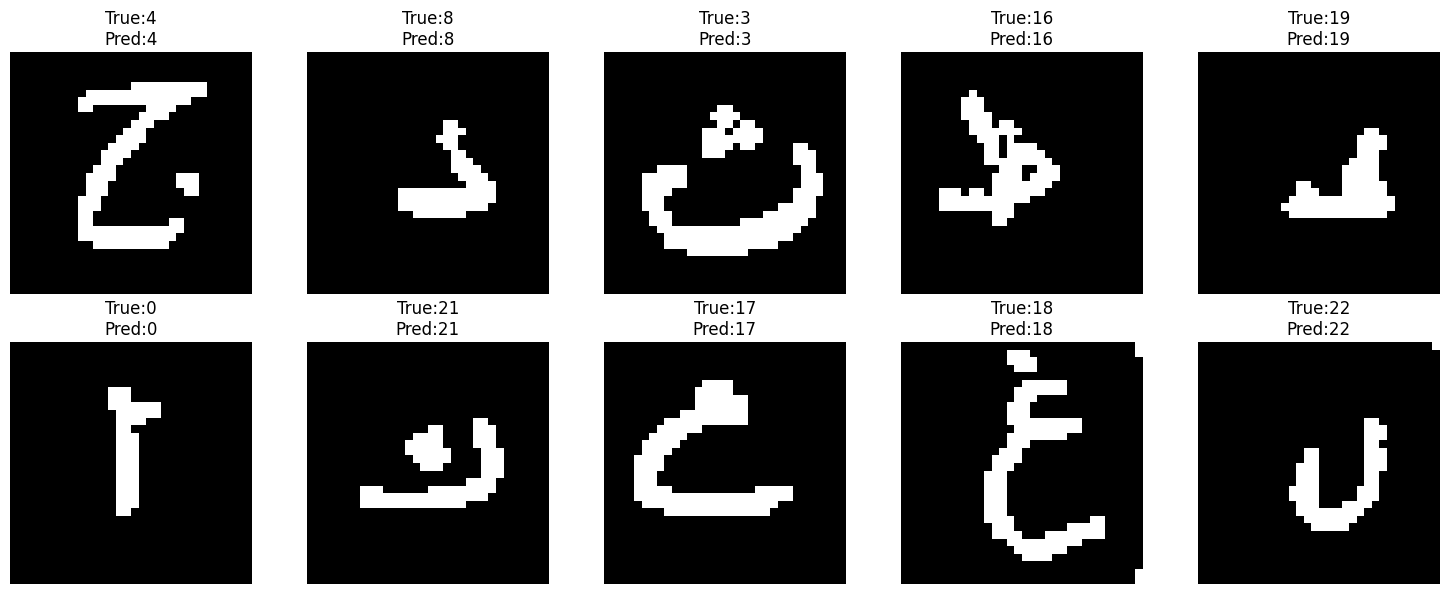

In [19]:
# Correctly Classified Images


correct = np.where(y_test == y_pred)[0]

plt.figure(figsize=(15,6))

for i in range(10):

    index = correct[i]

    plt.subplot(2,5,i+1)

    plt.imshow(X_test[index].reshape(32,32), cmap="gray")

    plt.title(f"True:{y_test[index]}\nPred:{y_pred[index]}")

    plt.axis("off")

plt.tight_layout()

plt.show()

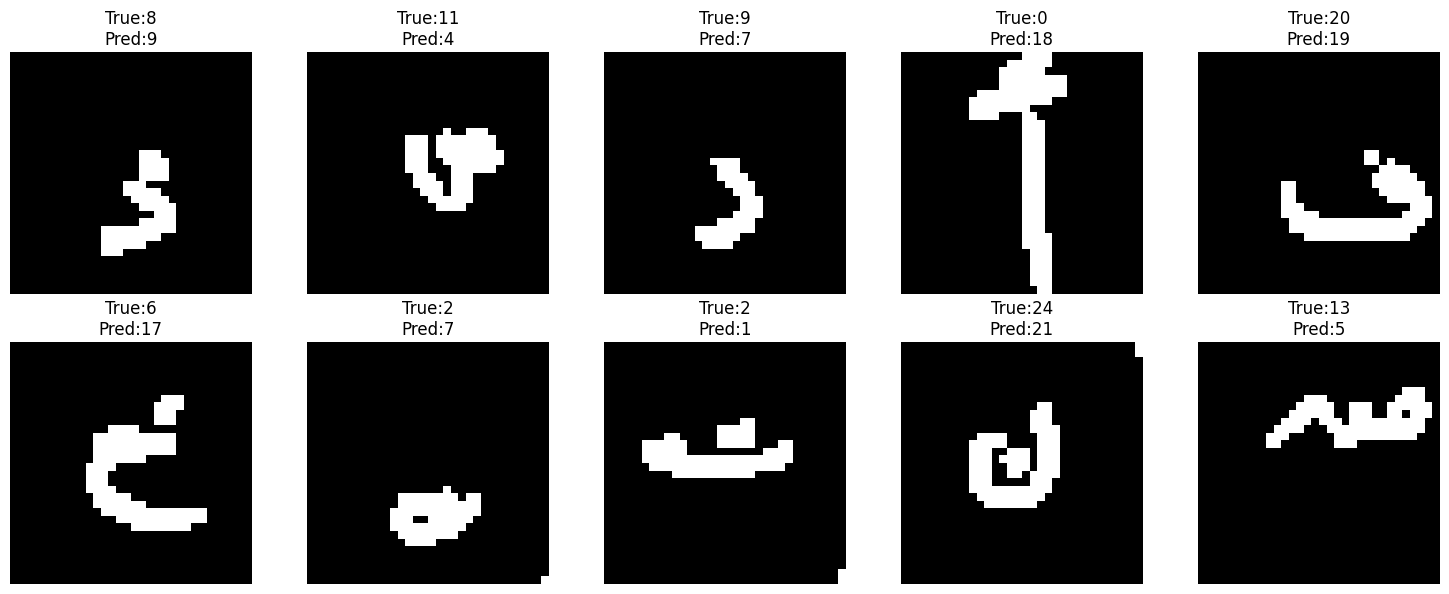

In [20]:
# Incorrectly Classified Images


incorrect = np.where(y_test != y_pred)[0]

plt.figure(figsize=(15,6))

for i in range(10):

    index = incorrect[i]

    plt.subplot(2,5,i+1)

    plt.imshow(X_test[index].reshape(32,32), cmap="gray")

    plt.title(f"True:{y_test[index]}\nPred:{y_pred[index]}")

    plt.axis("off")

plt.tight_layout()

plt.show()

In [21]:
# Save Model


import joblib

joblib.dump(mlp, "Arabic_MLP_Model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


# Conclusion

In this project, a Multi-Layer Perceptron (MLP) classifier was developed for handwritten Arabic character recognition using the Arabic Handwritten Characters Dataset (AHCD).

The character images were preprocessed by converting them into grayscale, normalizing pixel values, and flattening each 32×32 image into a one-dimensional feature vector. The MLP model was trained on the training dataset and evaluated on unseen test images.

The trained model achieved approximately **79% classification accuracy**. Its performance was further evaluated using Precision, Recall, F1-score, Classification Report, and Confusion Matrix. Correctly classified and incorrectly classified handwritten characters were also visualized to analyze the model’s strengths and weaknesses.

The results show that an MLP can effectively classify handwritten Arabic characters, although some errors occur due to similar character shapes and variations in handwriting. More advanced deep learning models, such as Convolutional Neural Networks (CNNs), may further improve classification accuracy.